In [1]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt

Tutorial: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

In [2]:
adata = sc.read_h5ad(
    "/data/MERFISH/20241108_Bartelle_MouseMERFISH_LC/qi2labdatastore/mtx_output/Imputed_Hammond.h5ad"
)
adata

AnnData object with n_obs × n_vars = 7226 × 10570
    obs: 'n_genes', 'uniform_density', 'rna_count_based_density'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'sparsity', 'is_training'
    uns: 'overlap_genes', 'training_genes'

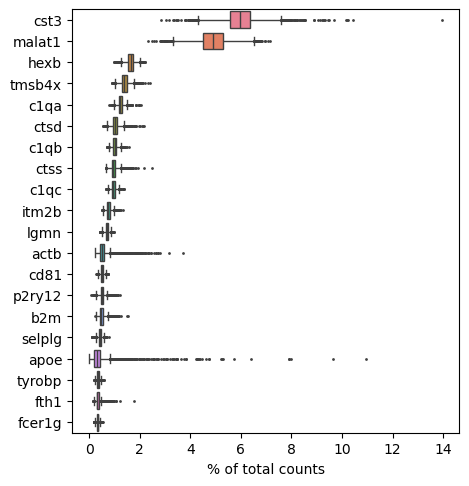

In [3]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [4]:
sc.pp.calculate_qc_metrics(
    adata, percent_top=None, log1p=True, inplace=True
)

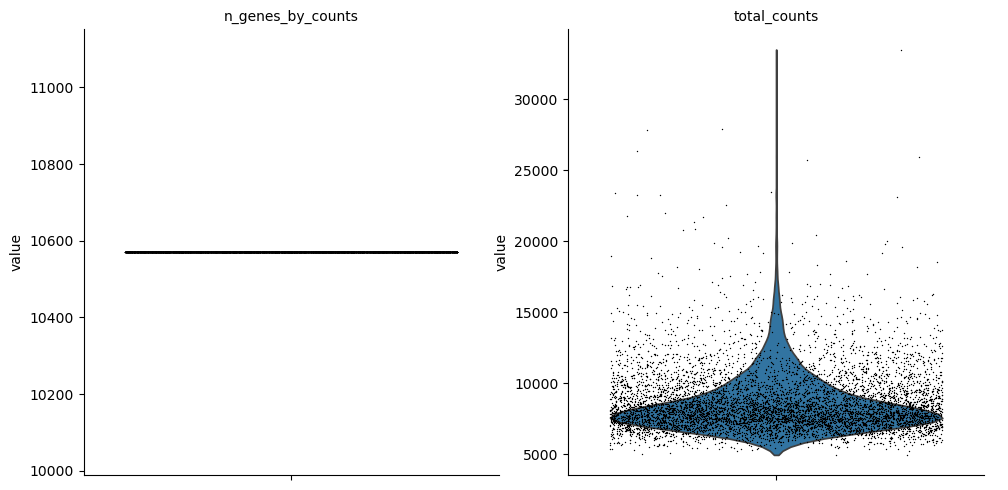

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

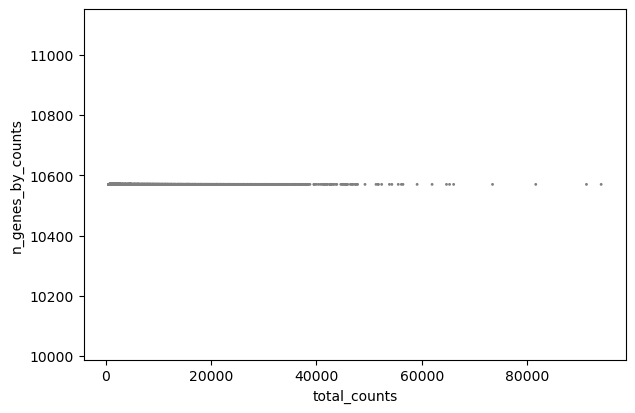

In [8]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [6]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)

In [7]:
# Logarithmize the data
sc.pp.log1p(adata)

In [10]:
'''
Finding highly variable genes seems to affect the final results a lot!
'''
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
# sc.pl.highly_variable_genes(adata)

In [11]:
# sc.pp.highly_variable_genes(adata, n_top_genes=30)
sc.tl.pca(adata)

In [12]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


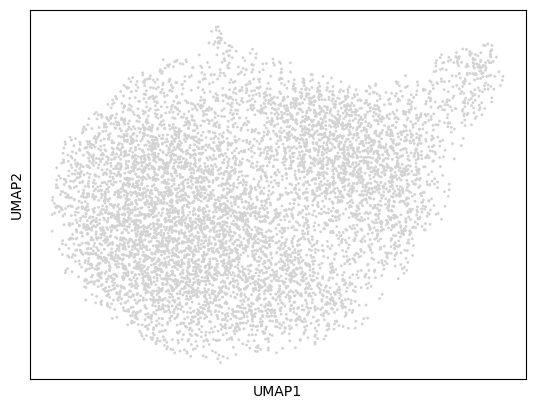

In [13]:
sc.tl.umap(adata)
sc.pl.umap(adata)

In [14]:
# Clustering the data
resolution_list = [0.1, 0.3, 0.5, 1.0]
for res in resolution_list:
    sc.tl.leiden(
        adata,
        resolution=res,
        flavor="igraph",
        n_iterations=2,
        key_added=f"leiden_res_{res:4.2f}"
        )

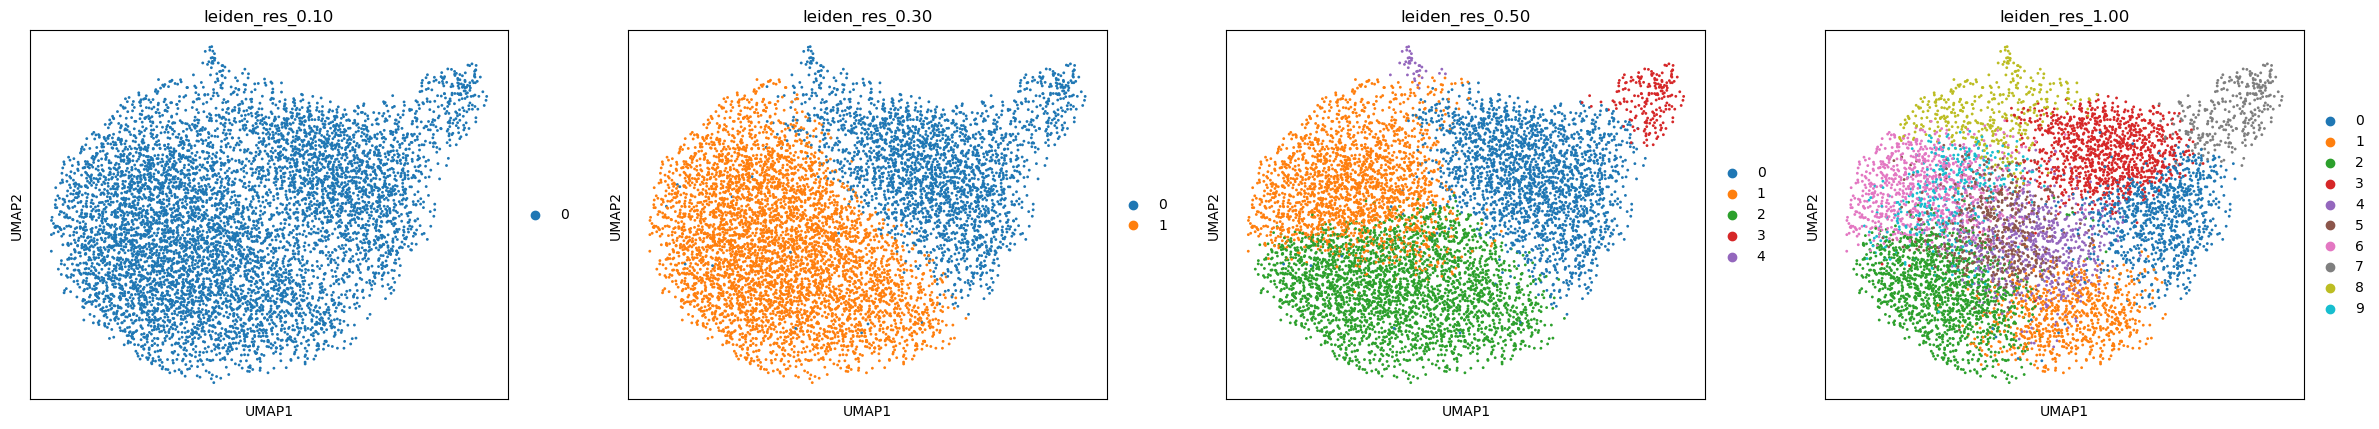

In [15]:
leiden_keys = [f"leiden_res_{res:4.2f}" for res in resolution_list]
sc.pl.umap(adata, color=leiden_keys)

## Modules

In [16]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_combined_modules.csv",
    index_col=0)
modules_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
0,Gfm2,Ifitm3,Tmsb4x,Bmp2k,Ifitm3,Gm11808,Ftl1,Cd52,Ftl1,Jun
1,Gm26917,Ifi204,Fth1,Bhlhe41,Ifit3,Gm8730,Gapdh,Ifi27l2a,Gapdh,Btg2
2,Gm8730,Oasl2,B2m,Notch2,Isg15,Gm2000,Fau,Cst7,Gm10076,Tmem119
3,Gm20721,Ifi27l2a,Eef1a1,Slc39a1,Ifi204,Gm10116,Cd63,Ifitm3,Uba52,Crybb1
4,Gm10116,Ifit3,Fau,Ptafr,Oasl2,Gm10073,Lag3,Irf7,Serf2,Slc2a5


In [20]:
modules_df = modules_df.map(lambda x: x.lower() if isinstance(x, str) else x)
modules_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
0,gfm2,ifitm3,tmsb4x,bmp2k,ifitm3,gm11808,ftl1,cd52,ftl1,jun
1,gm26917,ifi204,fth1,bhlhe41,ifit3,gm8730,gapdh,ifi27l2a,gapdh,btg2
2,gm8730,oasl2,b2m,notch2,isg15,gm2000,fau,cst7,gm10076,tmem119
3,gm20721,ifi27l2a,eef1a1,slc39a1,ifi204,gm10116,cd63,ifitm3,uba52,crybb1
4,gm10116,ifit3,fau,ptafr,oasl2,gm10073,lag3,irf7,serf2,slc2a5


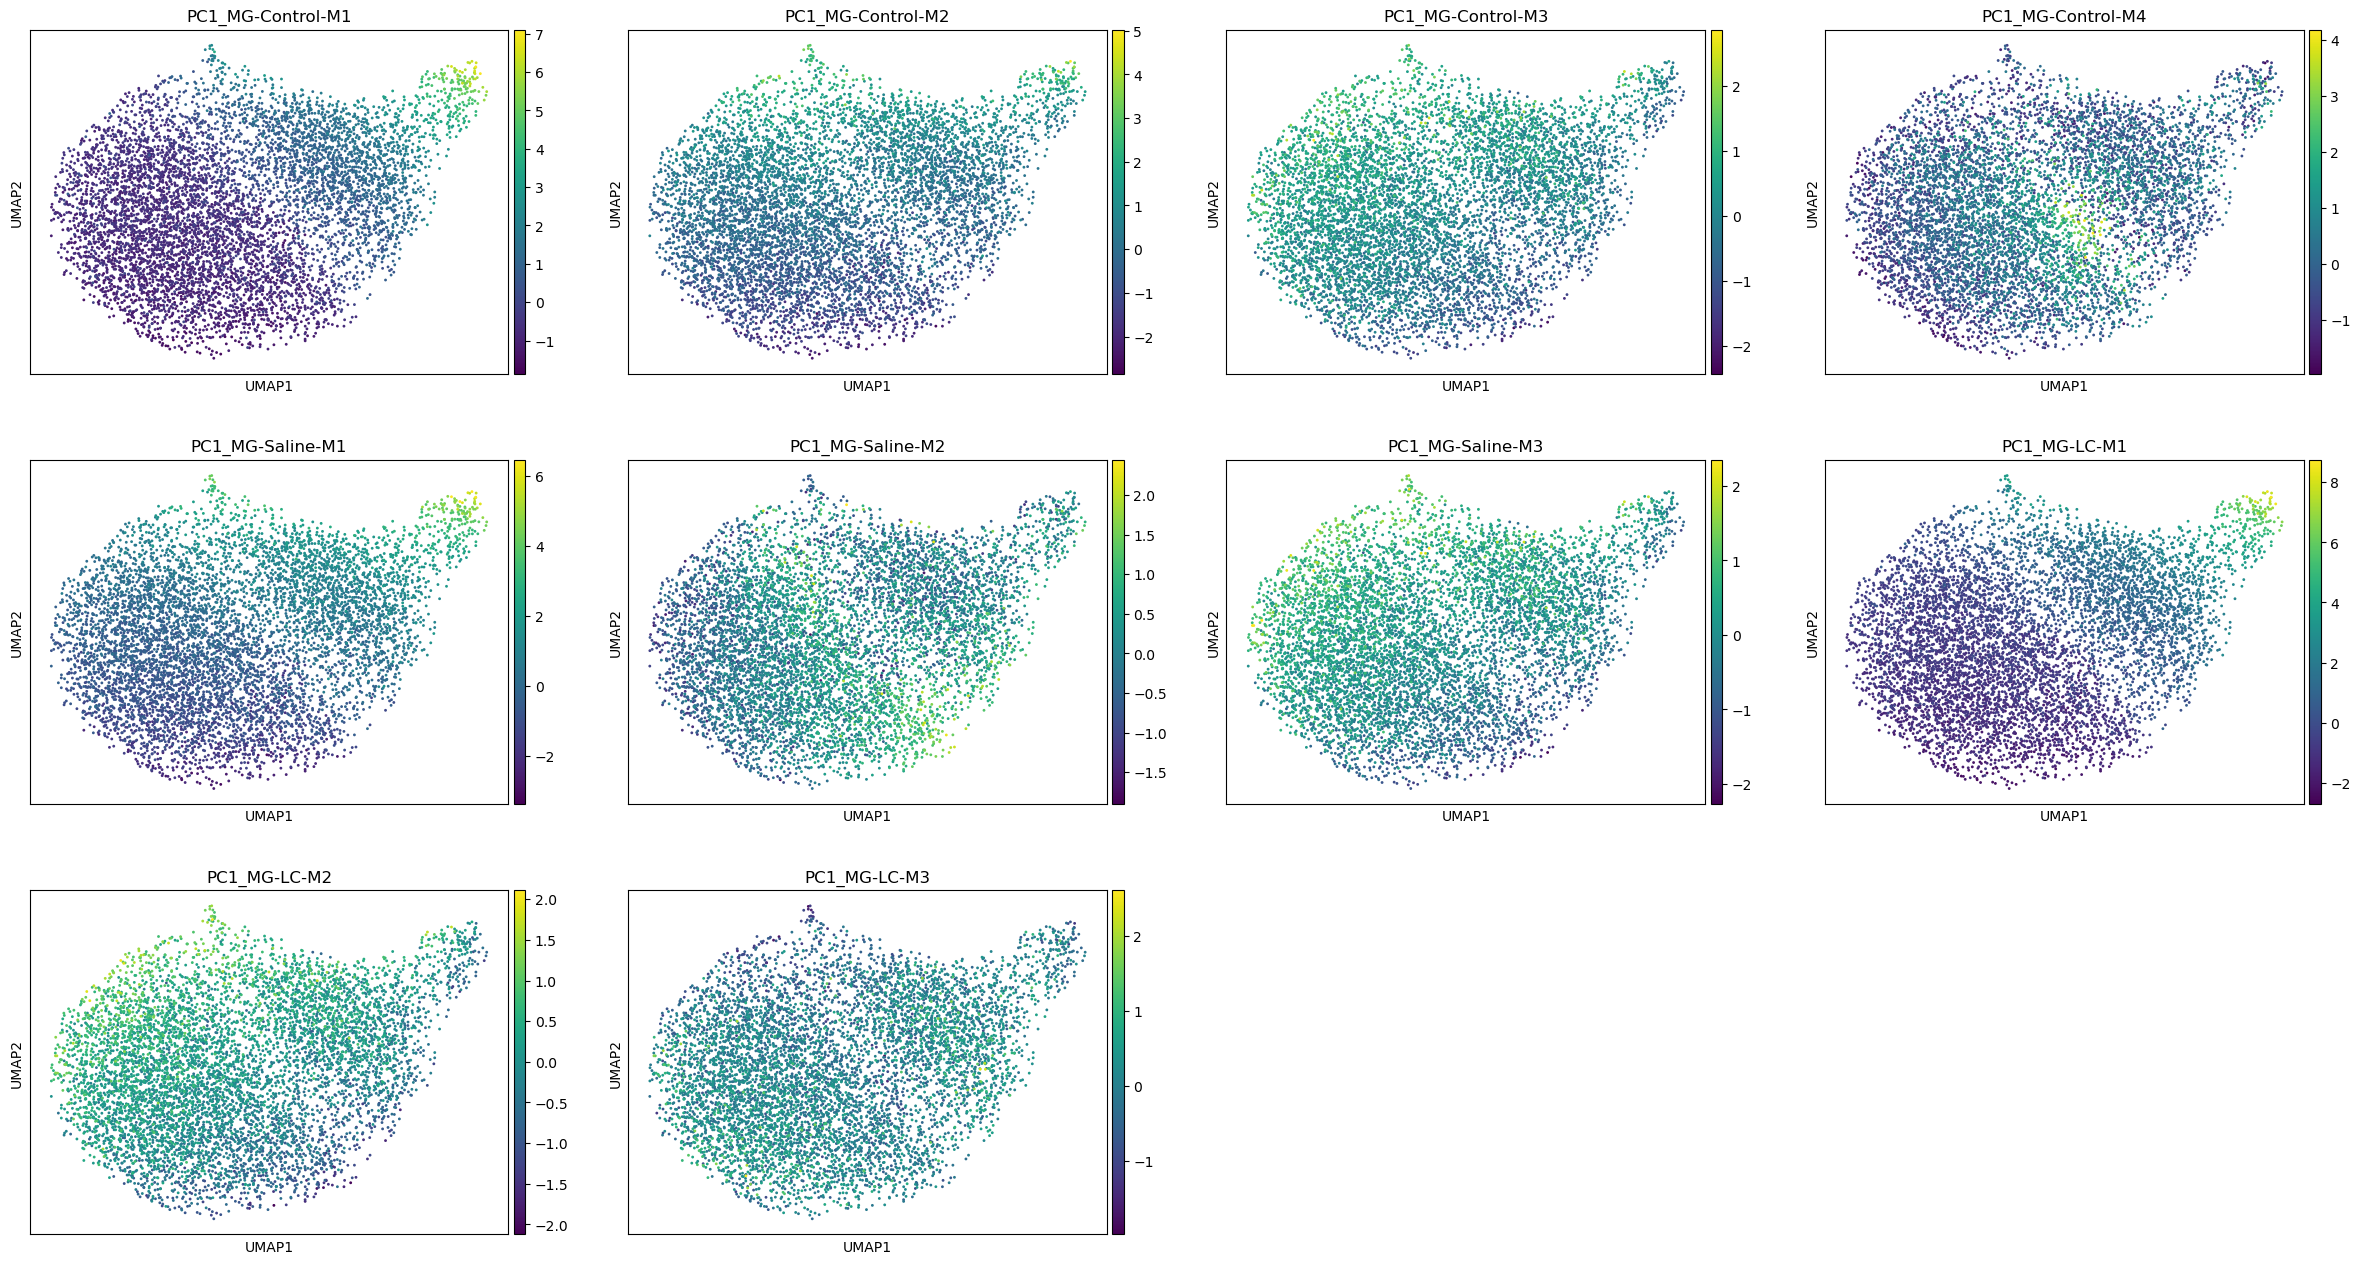

In [21]:
# Iterate over each module in the modules_df dataframe
for module_name in modules_df.columns:
    # Get the genes for the current module
    module_genes = modules_df[module_name].dropna().tolist()
    
    # Find the common genes between the module and the adata object
    common_genes = adata.var_names.intersection(module_genes)
    
    # Subset the adata object to include only the common genes
    adata_subset = adata[:, common_genes].copy()
    
    # Perform PCA on the subset
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the adata object as a new observation
    adata.obs[f"PC1_{module_name}"] = pc1_values

# Visualize all modules together on UMAP
module_colors = [f"PC1_{module_name}" for module_name in modules_df.columns]
sc.pl.umap(adata, color=module_colors)